# PS2 — Read Protocol & Orbit Classification
## Option C: HH Delay-Directed Orbit Selection
### HHSMC Project — Corrected Pipeline — February 2026

**Purpose:** Design and calibrate a read protocol that identifies which orbit the neuron is currently executing, based on observed ISI patterns.

**Prerequisite:** PS1 completed, Gate PS-G1 PASSED (14 library orbits, 12 locked)

**Phases:**
- **A** — Build orbit fingerprint templates from clean simulations
- **B** — Clean classification confusion matrix
- **C** — Calibrate observation window (min ISIs for reliable read)
- **D** — Noise robustness (current noise, K jitter, τ jitter)
- **E** — Gate PS-G2 evaluation

**Gate PS-G2:** ≥95% clean at 10 ISIs, ≥90% at σ=0.5, ≥85% at ±10% jitter, window ≤20 ISIs

**Numba fixes:** NO `cache=True`, NO `np.clip`

## CELL 1 — Setup and Imports

In [1]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import json, os, time, warnings
from datetime import datetime
from collections import Counter

# --- Google Drive Mount ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PS1_DIR = '/content/drive/My Drive/HHSMC/full_study/PS1_write_protocol'
    OUTPUT_DIR = '/content/drive/My Drive/HHSMC/full_study/PS2_read_protocol'
    ON_COLAB = True
except ImportError:
    PS1_DIR = './PS1_results'
    OUTPUT_DIR = './PS2_results'
    ON_COLAB = False

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"PS1 input:  {PS1_DIR}")
print(f"PS2 output: {OUTPUT_DIR}")
print(f"Timestamp:  {datetime.now().isoformat()}")
print(f"Phase PS2 — Read Protocol & Orbit Classification")

Mounted at /content/drive
PS1 input:  /content/drive/My Drive/HHSMC/full_study/PS1_write_protocol
PS2 output: /content/drive/My Drive/HHSMC/full_study/PS2_read_protocol
Timestamp:  2026-03-06T14:47:33.086999
Phase PS2 — Read Protocol & Orbit Classification


## CELL 2 — HH Model (V-shifted, rest = 0) — NO cache=True, NO np.clip

In [2]:
C_M  = 1.0
G_NA = 120.0
G_K  = 36.0
G_L  = 0.3
E_NA = 115.0
E_K  = -12.0
E_L  = 10.6
DT   = 0.01

@njit
def alpha_m(V):
    x = 25.0 - V
    if abs(x) < 1e-7:
        return 1.0
    return 0.1 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_m(V):
    return 4.0 * np.exp(-V / 18.0)

@njit
def alpha_h(V):
    return 0.07 * np.exp(-V / 20.0)

@njit
def beta_h(V):
    return 1.0 / (np.exp((30.0 - V) / 10.0) + 1.0)

@njit
def alpha_n(V):
    x = 10.0 - V
    if abs(x) < 1e-7:
        return 0.1
    return 0.01 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_n(V):
    return 0.125 * np.exp(-V / 80.0)

@njit
def clamp01(x):
    if x < 0.0:
        return 0.0
    if x > 1.0:
        return 1.0
    return x

@njit
def hh_rhs(V, m, h, n, I_total):
    I_Na = G_NA * m*m*m * h * (V - E_NA)
    I_K  = G_K * n*n*n*n * (V - E_K)
    I_L  = G_L * (V - E_L)
    dV = (I_total - I_Na - I_K - I_L) / C_M
    dm = alpha_m(V) * (1.0 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1.0 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1.0 - n) - beta_n(V) * n
    return dV, dm, dh, dn

@njit
def hh_steady_state(V):
    am = alpha_m(V); bm = beta_m(V)
    ah = alpha_h(V); bh = beta_h(V)
    an = alpha_n(V); bn = beta_n(V)
    return am/(am+bm), ah/(ah+bh), an/(an+bn)

## CELL 3 — Simulation Engine (clean + noisy variants)

In [3]:
@njit
def rk4_step(V, m, h, n, I_bias, K, V_delayed, dt):
    I_ctrl = K * (V_delayed - V)
    I_total = I_bias + I_ctrl
    dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)

    Vk2 = V + 0.5*dt*dV1
    mk2 = m + 0.5*dt*dm1; hk2 = h + 0.5*dt*dh1; nk2 = n + 0.5*dt*dn1
    I2 = I_bias + K * (V_delayed - Vk2)
    dV2, dm2, dh2, dn2 = hh_rhs(Vk2, mk2, hk2, nk2, I2)

    Vk3 = V + 0.5*dt*dV2
    mk3 = m + 0.5*dt*dm2; hk3 = h + 0.5*dt*dh2; nk3 = n + 0.5*dt*dn2
    I3 = I_bias + K * (V_delayed - Vk3)
    dV3, dm3, dh3, dn3 = hh_rhs(Vk3, mk3, hk3, nk3, I3)

    Vk4 = V + dt*dV3
    mk4 = m + dt*dm3; hk4 = h + dt*dh3; nk4 = n + dt*dn3
    I4 = I_bias + K * (V_delayed - Vk4)
    dV4, dm4, dh4, dn4 = hh_rhs(Vk4, mk4, hk4, nk4, I4)

    V_new = V + (dt/6.0)*(dV1 + 2*dV2 + 2*dV3 + dV4)
    m_new = clamp01(m + (dt/6.0)*(dm1 + 2*dm2 + 2*dm3 + dm4))
    h_new = clamp01(h + (dt/6.0)*(dh1 + 2*dh2 + 2*dh3 + dh4))
    n_new = clamp01(n + (dt/6.0)*(dn1 + 2*dn2 + 2*dn3 + dn4))

    return V_new, m_new, h_new, n_new


@njit
def simulate_clean(I_bias, K, tau_ms, T_total_ms, dt=0.01):
    """Clean simulation — no noise. For building templates."""
    n_steps = int(T_total_ms / dt)
    buf_size = max(int(tau_ms / dt), 1)

    V = 0.0
    m, h, n = hh_steady_state(V)

    V_buf = np.zeros(buf_size)
    for ws in range(buf_size):
        V_new, m, h, n = rk4_step(V, m, h, n, I_bias, 0.0, V, dt)
        V_buf[ws % buf_size] = V_new
        V = V_new
    buf_idx = 0

    max_spikes = int(T_total_ms / 2) + 100
    spike_times = np.empty(max_spikes)
    n_spikes = 0
    V_prev = V

    for step in range(n_steps):
        V_delayed = V_buf[buf_idx]
        V_new, m_new, h_new, n_new = rk4_step(V, m, h, n, I_bias,
                                                K, V_delayed, dt)
        V_buf[buf_idx] = V_new
        buf_idx = (buf_idx + 1) % buf_size

        if V_prev <= 0.0 and V_new > 0.0:
            if n_spikes < max_spikes:
                spike_times[n_spikes] = step * dt
                n_spikes += 1

        V_prev = V_new
        V = V_new; m = m_new; h = h_new; n = n_new

    return spike_times[:n_spikes]


@njit
def simulate_noisy(I_bias, K, tau_ms, T_total_ms, noise_sigma,
                   K_jitter_frac, tau_jitter_frac, seed, dt=0.01):
    """
    Noisy simulation for read-robustness testing.

    noise_sigma: std of additive Gaussian current noise (μA/cm²)
    K_jitter_frac: fractional jitter on K (e.g. 0.05 = ±5%)
    tau_jitter_frac: fractional jitter on tau
    """
    np.random.seed(seed)
    n_steps = int(T_total_ms / dt)

    # Apply parameter jitter (fixed for this run)
    K_actual = K * (1.0 + K_jitter_frac * (2.0 * np.random.random() - 1.0))
    tau_actual = tau_ms * (1.0 + tau_jitter_frac * (2.0 * np.random.random() - 1.0))
    if K_actual < 0.0:
        K_actual = 0.0
    if tau_actual < 0.5:
        tau_actual = 0.5

    buf_size = max(int(tau_actual / dt), 1)

    V = 0.0
    m, h, n = hh_steady_state(V)

    V_buf = np.zeros(buf_size)
    for ws in range(buf_size):
        V_new, m, h, n = rk4_step(V, m, h, n, I_bias, 0.0, V, dt)
        V_buf[ws % buf_size] = V_new
        V = V_new
    buf_idx = 0

    max_spikes = int(T_total_ms / 2) + 100
    spike_times = np.empty(max_spikes)
    n_spikes = 0
    V_prev = V

    # Noise scale per step: σ * √(dt)
    noise_scale = noise_sigma * np.sqrt(dt)

    for step in range(n_steps):
        V_delayed = V_buf[buf_idx]

        # Add current noise
        I_noise = noise_scale * np.random.randn()
        I_ctrl = K_actual * (V_delayed - V)
        I_total = I_bias + I_ctrl + I_noise

        # RK4 with noisy current (noise only at first substep for stability)
        dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)

        Vk2 = V + 0.5*dt*dV1
        mk2 = m + 0.5*dt*dm1; hk2 = h + 0.5*dt*dh1; nk2 = n + 0.5*dt*dn1
        I2 = I_bias + K_actual * (V_delayed - Vk2)
        dV2, dm2, dh2, dn2 = hh_rhs(Vk2, mk2, hk2, nk2, I2)

        Vk3 = V + 0.5*dt*dV2
        mk3 = m + 0.5*dt*dm2; hk3 = h + 0.5*dt*dh2; nk3 = n + 0.5*dt*dn2
        I3 = I_bias + K_actual * (V_delayed - Vk3)
        dV3, dm3, dh3, dn3 = hh_rhs(Vk3, mk3, hk3, nk3, I3)

        Vk4 = V + dt*dV3
        mk4 = m + dt*dm3; hk4 = h + dt*dh3; nk4 = n + dt*dn3
        I4 = I_bias + K_actual * (V_delayed - Vk4)
        dV4, dm4, dh4, dn4 = hh_rhs(Vk4, mk4, hk4, nk4, I4)

        V_new = V + (dt/6.0)*(dV1 + 2*dV2 + 2*dV3 + dV4)
        m_new = clamp01(m + (dt/6.0)*(dm1 + 2*dm2 + 2*dm3 + dm4))
        h_new = clamp01(h + (dt/6.0)*(dh1 + 2*dh2 + 2*dh3 + dh4))
        n_new = clamp01(n + (dt/6.0)*(dn1 + 2*dn2 + 2*dn3 + dn4))

        V_buf[buf_idx] = V_new
        buf_idx = (buf_idx + 1) % buf_size

        if V_prev <= 0.0 and V_new > 0.0:
            if n_spikes < max_spikes:
                spike_times[n_spikes] = step * dt
                n_spikes += 1

        V_prev = V_new
        V = V_new; m = m_new; h = h_new; n = n_new

    return spike_times[:n_spikes]

## CELL 4 — Load PS1 Library

In [4]:
def load_ps1_library(ps1_dir):
    """Load orbit library and settling results from PS1."""
    lib_path = os.path.join(ps1_dir, 'PS1_library.json')
    settle_path = os.path.join(ps1_dir, 'PS1_settling_results.json')

    with open(lib_path, 'r') as f:
        library = json.load(f)

    settling = None
    if os.path.exists(settle_path):
        with open(settle_path, 'r') as f:
            settling = json.load(f)

    print(f"Loaded PS1 library: {len(library)} orbit types")
    cats = {}
    for o in library:
        c = o['category']
        cats[c] = cats.get(c, 0) + 1
    print(f"Categories: {cats}")

    # Identify locked orbits (from PS1 settling)
    locked_idx = set()
    if settling:
        for s in settling:
            if s['lock_rate'] >= 0.8:
                locked_idx.add(s['lib_idx'])
        print(f"Locked orbits (≥80%): {len(locked_idx)}/{len(library)}")

    return library, settling, locked_idx

## CELL 5 — Build Orbit Fingerprint Templates (Phase A)

In [5]:
def build_templates(library, locked_idx, I_bias, T_sim=5000.0,
                    T_transient=1000.0, n_template_runs=5):
    """
    Phase A: Generate clean ISI fingerprint templates for each locked orbit.

    For each orbit, run n_template_runs clean simulations, collect ISIs
    after transient, and build a statistical template:
      - isi_mean, isi_std
      - pattern_period (from autocorrelation)
      - isi_histogram (binned distribution)
      - raw ISI samples for KDE

    Returns
    -------
    templates : list of dicts, one per locked orbit
    """
    print(f"\nPhase A: Building orbit templates")
    print(f"  {len(locked_idx)} locked orbits × {n_template_runs} runs")
    print(f"  T_sim={T_sim:.0f}ms, T_transient={T_transient:.0f}ms")

    # JIT warmup
    print("  JIT warmup...", end=" ", flush=True)
    _ = simulate_clean(I_bias, 0.5, 50.0, 200.0, DT)
    _ = simulate_noisy(I_bias, 0.5, 50.0, 200.0, 0.1, 0.0, 0.0, 42, DT)
    print("done.")

    templates = []

    for orb in library:
        idx = orb['lib_idx']
        if idx not in locked_idx:
            continue

        K = orb['representative_K']
        tau = orb['representative_tau']
        cat = orb['category']

        all_isis = []
        for run in range(n_template_runs):
            spk = simulate_clean(I_bias, K, tau, T_sim, DT)
            post_spk = spk[spk > T_transient]
            if len(post_spk) >= 3:
                isis = np.diff(post_spk)
                all_isis.extend(isis.tolist())

        if len(all_isis) < 10:
            print(f"  [{idx}] {cat}: insufficient spikes, skipping")
            continue

        all_isis = np.array(all_isis)

        # Template statistics
        tmpl = {
            'lib_idx': idx,
            'type_id': orb['type_id'],
            'category': cat,
            'K': K,
            'tau_ms': tau,
            'pattern_length': orb['pattern_length'],
            'isi_mean': float(np.mean(all_isis)),
            'isi_std': float(np.std(all_isis)),
            'isi_cv': float(np.std(all_isis) / np.mean(all_isis)),
            'isi_min': float(np.min(all_isis)),
            'isi_max': float(np.max(all_isis)),
            'isi_median': float(np.median(all_isis)),
            'n_samples': len(all_isis),
        }

        # Histogram (for distribution-based matching)
        hist_bins = np.linspace(max(0, tmpl['isi_mean'] - 3*tmpl['isi_std'] - 5),
                                tmpl['isi_mean'] + 3*tmpl['isi_std'] + 5, 51)
        hist_counts, hist_edges = np.histogram(all_isis, bins=hist_bins,
                                                density=True)
        tmpl['hist_counts'] = hist_counts.tolist()
        tmpl['hist_edges'] = hist_edges.tolist()

        # Pattern detection via sorted ISI cycle
        pl = orb['pattern_length']
        if pl > 1 and len(all_isis) >= pl * 3:
            # Extract pattern by folding ISIs at pattern_length
            n_complete = (len(all_isis) // pl) * pl
            folded = all_isis[:n_complete].reshape(-1, pl)
            pattern_template = np.mean(folded, axis=0).tolist()
            pattern_std = np.std(folded, axis=0).tolist()
            tmpl['pattern_template'] = pattern_template
            tmpl['pattern_std'] = pattern_std
        else:
            tmpl['pattern_template'] = [tmpl['isi_mean']]
            tmpl['pattern_std'] = [tmpl['isi_std']]

        templates.append(tmpl)
        print(f"  [{idx}] {cat:>10} ISI={tmpl['isi_mean']:6.2f}±{tmpl['isi_std']:5.2f}ms "
              f"({tmpl['n_samples']} samples, plen={pl})")

    print(f"\n  Templates built: {len(templates)}")
    return templates

## CELL 6 — ISI-Based Orbit Classifier (Phase B)

In [6]:
def classify_orbit_from_isis(isis, templates, method='combined'):
    """
    Classify which orbit generated the observed ISI sequence.

    Methods:
      'mean': nearest ISI mean
      'mahalanobis': Mahalanobis distance using mean and std
      'pattern': pattern template matching (for bursting orbits)
      'combined': weighted combination of mean + pattern

    Returns
    -------
    best_idx : int — lib_idx of best matching template
    confidence : float — classification confidence (0–1)
    scores : dict — score per template
    """
    if len(isis) < 1:
        return -1, 0.0, {}

    obs_mean = np.mean(isis)
    obs_std = np.std(isis) if len(isis) > 1 else 0.0

    scores = {}

    for tmpl in templates:
        tidx = tmpl['lib_idx']

        # === Mean distance score ===
        d_mean = abs(obs_mean - tmpl['isi_mean'])
        # Normalize by template spread
        sigma = max(tmpl['isi_std'], 0.5)  # floor to avoid div-by-zero
        z_mean = d_mean / sigma
        s_mean = np.exp(-0.5 * z_mean * z_mean)

        if method == 'mean':
            scores[tidx] = s_mean
            continue

        # === Pattern matching score ===
        s_pattern = 0.0
        pat = tmpl['pattern_template']
        pl = len(pat)

        if pl > 1 and len(isis) >= pl:
            # Align observed ISIs to pattern
            best_pattern_score = 0.0
            # Try all starting alignments
            n_try = min(pl, len(isis) - pl + 1)
            for offset in range(n_try):
                segment = isis[offset:offset + pl]
                if len(segment) < pl:
                    break
                # Normalized correlation
                pat_arr = np.array(pat)
                pat_mean = np.mean(pat_arr)
                seg_mean = np.mean(segment)
                num = np.sum((segment - seg_mean) * (pat_arr - pat_mean))
                den = (np.sqrt(np.sum((segment - seg_mean)**2)) *
                       np.sqrt(np.sum((pat_arr - pat_mean)**2)))
                if den > 1e-10:
                    corr = num / den
                else:
                    corr = 0.0
                # Also check ISI-level accuracy
                rel_err = np.mean(np.abs(segment - pat_arr) / (pat_arr + 0.1))
                acc_score = np.exp(-2.0 * rel_err)

                combined_pat = 0.5 * max(corr, 0.0) + 0.5 * acc_score
                if combined_pat > best_pattern_score:
                    best_pattern_score = combined_pat

            s_pattern = best_pattern_score
        else:
            # Tonic-like: pattern score = mean accuracy
            s_pattern = s_mean

        if method == 'pattern':
            scores[tidx] = s_pattern
            continue

        # === Combined ===
        scores[tidx] = 0.6 * s_mean + 0.4 * s_pattern

    if not scores:
        return -1, 0.0, scores

    best_idx = max(scores, key=scores.get)
    best_score = scores[best_idx]

    # Confidence: ratio of best to second-best
    sorted_scores = sorted(scores.values(), reverse=True)
    if len(sorted_scores) >= 2 and sorted_scores[1] > 0:
        margin = sorted_scores[0] - sorted_scores[1]
        confidence = min(margin / (sorted_scores[1] + 1e-10), 1.0)
    else:
        confidence = 1.0

    return best_idx, confidence, scores

## CELL 7 — Observation Window Calibration (Phase C)

In [7]:
def calibrate_observation_window(templates, library, locked_idx, I_bias,
                                 window_sizes=None, n_trials=50):
    """
    Phase C: Find minimum number of ISIs needed for reliable classification.

    For each window size (number of ISIs observed), simulate each orbit
    and test classification accuracy.

    Returns
    -------
    calibration : dict with accuracy per (orbit, window_size)
    """
    if window_sizes is None:
        window_sizes = [3, 5, 8, 10, 15, 20, 30, 50]

    locked_lib = [o for o in library if o['lib_idx'] in locked_idx]
    n_orbits = len(locked_lib)
    print(f"\nPhase C: Observation Window Calibration")
    print(f"  {n_orbits} orbits × {len(window_sizes)} windows × {n_trials} trials")
    print(f"  Window sizes (ISIs): {window_sizes}")

    # We need enough simulation time for the largest window
    max_isi_mean = max(t['isi_mean'] for t in templates)
    max_window = max(window_sizes)
    T_sim = 1000.0 + max_isi_mean * max_window * 2  # generous
    T_transient = 500.0

    accuracy_matrix = np.zeros((n_orbits, len(window_sizes)))
    confidence_matrix = np.zeros((n_orbits, len(window_sizes)))
    t0 = time.time()

    for oi, orb in enumerate(locked_lib):
        idx = orb['lib_idx']
        K = orb['representative_K']
        tau = orb['representative_tau']

        for wi, n_isis in enumerate(window_sizes):
            correct = 0
            total_conf = 0.0

            for trial in range(n_trials):
                # Run clean simulation
                spk = simulate_clean(I_bias, K, tau, T_sim, DT)
                post_spk = spk[spk > T_transient]

                if len(post_spk) < n_isis + 1:
                    continue

                isis = np.diff(post_spk)

                if len(isis) < n_isis:
                    continue

                # Random window start
                if len(isis) > n_isis:
                    start = np.random.randint(0, len(isis) - n_isis)
                else:
                    start = 0
                obs_isis = isis[start:start + n_isis]

                pred_idx, conf, _ = classify_orbit_from_isis(obs_isis, templates)
                if pred_idx == idx:
                    correct += 1
                total_conf += conf

            acc = correct / n_trials if n_trials > 0 else 0
            avg_conf = total_conf / n_trials if n_trials > 0 else 0
            accuracy_matrix[oi, wi] = acc
            confidence_matrix[oi, wi] = avg_conf

        print(f"  [{oi+1:2d}/{n_orbits}] {orb['category']:>10} "
              f"ISI={orb['isi_mean']:6.1f}: "
              + " ".join(f"{accuracy_matrix[oi,w]:4.0%}" for w in range(len(window_sizes))))

    elapsed = time.time() - t0
    print(f"\nPhase C complete in {elapsed:.1f}s")

    # Find minimum window for ≥95% accuracy per orbit
    min_windows = {}
    for oi, orb in enumerate(locked_lib):
        for wi, n_isis in enumerate(window_sizes):
            if accuracy_matrix[oi, wi] >= 0.95:
                min_windows[orb['lib_idx']] = n_isis
                break
        else:
            min_windows[orb['lib_idx']] = -1  # never reached 95%

    # Overall accuracy per window
    mean_acc = np.mean(accuracy_matrix, axis=0)
    print(f"\n  Mean accuracy by window size:")
    for wi, n_isis in enumerate(window_sizes):
        print(f"    {n_isis:3d} ISIs: {mean_acc[wi]:.1%}")

    return {
        'accuracy_matrix': accuracy_matrix,
        'confidence_matrix': confidence_matrix,
        'window_sizes': window_sizes,
        'orbit_indices': [o['lib_idx'] for o in locked_lib],
        'min_window_95': min_windows,
        'mean_accuracy': mean_acc.tolist(),
    }

## CELL 8 — Noise Robustness Testing (Phase D)

In [8]:
def test_noise_robustness(templates, library, locked_idx, I_bias,
                          noise_levels=None, K_jitter_levels=None,
                          tau_jitter_levels=None,
                          n_isis_read=10, n_trials=50):
    """
    Phase D: Test classification under various noise conditions.

    Returns accuracy vs noise level for each orbit.
    """
    if noise_levels is None:
        noise_levels = [0.0, 0.1, 0.2, 0.5, 1.0, 2.0, 3.0, 5.0]
    if K_jitter_levels is None:
        K_jitter_levels = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20]
    if tau_jitter_levels is None:
        tau_jitter_levels = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20]

    locked_lib = [o for o in library if o['lib_idx'] in locked_idx]
    n_orbits = len(locked_lib)

    T_sim = 3000.0
    T_transient = 500.0

    # --- Test 1: Current noise ---
    print(f"\nPhase D: Noise Robustness Testing")
    print(f"  Test 1: Current noise ({len(noise_levels)} levels × {n_orbits} orbits × {n_trials} trials)")

    noise_accuracy = np.zeros((n_orbits, len(noise_levels)))
    t0 = time.time()

    for oi, orb in enumerate(locked_lib):
        idx = orb['lib_idx']
        K = orb['representative_K']
        tau = orb['representative_tau']

        for ni, sigma in enumerate(noise_levels):
            correct = 0
            for trial in range(n_trials):
                seed = oi * 10000 + ni * 100 + trial
                spk = simulate_noisy(I_bias, K, tau, T_sim, sigma,
                                     0.0, 0.0, seed, DT)
                post_spk = spk[spk > T_transient]
                if len(post_spk) < n_isis_read + 1:
                    continue
                isis = np.diff(post_spk)
                if len(isis) < n_isis_read:
                    continue
                start = len(isis) - n_isis_read  # use last ISIs (steady state)
                obs = isis[start:start + n_isis_read]
                pred, _, _ = classify_orbit_from_isis(obs, templates)
                if pred == idx:
                    correct += 1

            noise_accuracy[oi, ni] = correct / n_trials

    print(f"  Current noise test: {time.time()-t0:.1f}s")
    mean_noise_acc = np.mean(noise_accuracy, axis=0)
    for ni, sigma in enumerate(noise_levels):
        print(f"    σ={sigma:4.1f} μA/cm²: {mean_noise_acc[ni]:.1%}")

    # --- Test 2: Parameter jitter (K) ---
    print(f"\n  Test 2: K jitter ({len(K_jitter_levels)} levels)")
    K_jitter_accuracy = np.zeros((n_orbits, len(K_jitter_levels)))
    t0 = time.time()

    for oi, orb in enumerate(locked_lib):
        idx = orb['lib_idx']
        K = orb['representative_K']
        tau = orb['representative_tau']

        for ji, jfrac in enumerate(K_jitter_levels):
            correct = 0
            for trial in range(n_trials):
                seed = 50000 + oi * 10000 + ji * 100 + trial
                spk = simulate_noisy(I_bias, K, tau, T_sim, 0.0,
                                     jfrac, 0.0, seed, DT)
                post_spk = spk[spk > T_transient]
                if len(post_spk) < n_isis_read + 1:
                    continue
                isis = np.diff(post_spk)
                if len(isis) < n_isis_read:
                    continue
                start = len(isis) - n_isis_read
                obs = isis[start:start + n_isis_read]
                pred, _, _ = classify_orbit_from_isis(obs, templates)
                if pred == idx:
                    correct += 1

            K_jitter_accuracy[oi, ji] = correct / n_trials

    print(f"  K jitter test: {time.time()-t0:.1f}s")
    mean_K_acc = np.mean(K_jitter_accuracy, axis=0)
    for ji, jfrac in enumerate(K_jitter_levels):
        print(f"    K±{jfrac:.0%}: {mean_K_acc[ji]:.1%}")

    # --- Test 3: Parameter jitter (τ) ---
    print(f"\n  Test 3: τ jitter ({len(tau_jitter_levels)} levels)")
    tau_jitter_accuracy = np.zeros((n_orbits, len(tau_jitter_levels)))
    t0 = time.time()

    for oi, orb in enumerate(locked_lib):
        idx = orb['lib_idx']
        K = orb['representative_K']
        tau = orb['representative_tau']

        for ti, jfrac in enumerate(tau_jitter_levels):
            correct = 0
            for trial in range(n_trials):
                seed = 100000 + oi * 10000 + ti * 100 + trial
                spk = simulate_noisy(I_bias, K, tau, T_sim, 0.0,
                                     0.0, jfrac, seed, DT)
                post_spk = spk[spk > T_transient]
                if len(post_spk) < n_isis_read + 1:
                    continue
                isis = np.diff(post_spk)
                if len(isis) < n_isis_read:
                    continue
                start = len(isis) - n_isis_read
                obs = isis[start:start + n_isis_read]
                pred, _, _ = classify_orbit_from_isis(obs, templates)
                if pred == idx:
                    correct += 1

            tau_jitter_accuracy[oi, ti] = correct / n_trials

    print(f"  τ jitter test: {time.time()-t0:.1f}s")
    mean_tau_acc = np.mean(tau_jitter_accuracy, axis=0)
    for ti, jfrac in enumerate(tau_jitter_levels):
        print(f"    τ±{jfrac:.0%}: {mean_tau_acc[ti]:.1%}")

    return {
        'noise_levels': noise_levels,
        'noise_accuracy': noise_accuracy,
        'K_jitter_levels': K_jitter_levels,
        'K_jitter_accuracy': K_jitter_accuracy,
        'tau_jitter_levels': tau_jitter_levels,
        'tau_jitter_accuracy': tau_jitter_accuracy,
        'n_isis_read': n_isis_read,
        'n_trials': n_trials,
    }

## CELL 9 — Gate PS-G2 Evaluation

In [9]:
def evaluate_gate_PS_G2(calibration, noise_data, templates, library):
    """
    Gate PS-G2: Read protocol viable?

    Criteria:
      G2a: Clean classification accuracy ≥ 95% with ≤ 10 ISIs
      G2b: Classification accuracy ≥ 90% with σ=0.5 μA/cm² current noise
      G2c: Classification accuracy ≥ 85% with ±10% parameter jitter (K or τ)
      G2d: Minimum observation window ≤ 20 ISIs for all orbits at ≥95%
    """
    print("\n" + "="*70)
    print("GATE PS-G2 — READ PROTOCOL VIABILITY")
    print("="*70)

    # G2a: Clean accuracy at 10 ISIs
    ws = calibration['window_sizes']
    if 10 in ws:
        wi_10 = ws.index(10)
    else:
        # Find closest to 10
        wi_10 = min(range(len(ws)), key=lambda i: abs(ws[i] - 10))
    clean_acc_10 = np.mean(calibration['accuracy_matrix'][:, wi_10])
    gate_a = clean_acc_10 >= 0.95
    print(f"\n  G2a — Clean accuracy at {ws[wi_10]} ISIs: {clean_acc_10:.1%}"
          f" {'✓ PASS' if gate_a else '✗ FAIL'} (gate: ≥95%)")

    # G2b: Noisy accuracy at σ=0.5
    nl = noise_data['noise_levels']
    if 0.5 in nl:
        ni_05 = nl.index(0.5)
    else:
        ni_05 = min(range(len(nl)), key=lambda i: abs(nl[i] - 0.5))
    noisy_acc_05 = np.mean(noise_data['noise_accuracy'][:, ni_05])
    gate_b = noisy_acc_05 >= 0.90
    print(f"  G2b — Noisy accuracy (σ={nl[ni_05]}): {noisy_acc_05:.1%}"
          f" {'✓ PASS' if gate_b else '✗ FAIL'} (gate: ≥90%)")

    # G2c: Parameter jitter ±10%
    kjl = noise_data['K_jitter_levels']
    tjl = noise_data['tau_jitter_levels']
    if 0.10 in kjl:
        ki_10 = kjl.index(0.10)
    else:
        ki_10 = min(range(len(kjl)), key=lambda i: abs(kjl[i] - 0.10))
    if 0.10 in tjl:
        ti_10 = tjl.index(0.10)
    else:
        ti_10 = min(range(len(tjl)), key=lambda i: abs(tjl[i] - 0.10))

    K_jitter_acc = np.mean(noise_data['K_jitter_accuracy'][:, ki_10])
    tau_jitter_acc = np.mean(noise_data['tau_jitter_accuracy'][:, ti_10])
    jitter_acc = min(K_jitter_acc, tau_jitter_acc)
    gate_c = jitter_acc >= 0.85
    print(f"  G2c — Jitter accuracy (K±{kjl[ki_10]:.0%}: {K_jitter_acc:.1%}, "
          f"τ±{tjl[ti_10]:.0%}: {tau_jitter_acc:.1%})"
          f" {'✓ PASS' if gate_c else '✗ FAIL'} (gate: min ≥85%)")

    # G2d: Minimum observation window
    min_ws = calibration['min_window_95']
    max_min_window = max(min_ws.values())
    all_within_20 = all(v <= 20 and v > 0 for v in min_ws.values())
    gate_d = all_within_20
    failing_orbits = {k: v for k, v in min_ws.items() if v > 20 or v < 0}
    print(f"  G2d — Max min-window (≥95%): {max_min_window} ISIs"
          f" {'✓ PASS' if gate_d else '✗ FAIL'} (gate: all ≤20)")
    if failing_orbits:
        print(f"         Failing: {failing_orbits}")

    gate_all = gate_a and gate_b and gate_c and gate_d

    if gate_all:
        print(f"\n  ✓✓✓ GATE PS-G2: PASS — Proceed to Phase PS3 ✓✓✓")
    else:
        print(f"\n  ✗✗✗ GATE PS-G2: CONDITIONAL ✗✗✗")
        if not gate_a:
            print(f"  Rec: Increase observation window or prune confusable orbits")
        if not gate_b:
            print(f"  Rec: Use majority voting over multiple reads")
        if not gate_c:
            print(f"  Rec: Increase parameter precision or widen ISI separation")
        if not gate_d:
            print(f"  Rec: Remove orbits requiring >20 ISIs")

    # Find critical noise threshold (accuracy drops below 90%)
    mean_noise_acc = np.mean(noise_data['noise_accuracy'], axis=0)
    critical_sigma = noise_data['noise_levels'][-1]
    for ni, sigma in enumerate(noise_data['noise_levels']):
        if mean_noise_acc[ni] < 0.90:
            critical_sigma = sigma
            break

    gate_result = {
        'decision': 'PASS' if gate_all else 'CONDITIONAL',
        'gate_a': gate_a,
        'gate_b': gate_b,
        'gate_c': gate_c,
        'gate_d': gate_d,
        'clean_accuracy_10isis': float(clean_acc_10),
        'noisy_accuracy_sigma05': float(noisy_acc_05),
        'K_jitter_accuracy_10pct': float(K_jitter_acc),
        'tau_jitter_accuracy_10pct': float(tau_jitter_acc),
        'max_min_window': int(max_min_window),
        'critical_noise_sigma': float(critical_sigma),
        'n_templates': len(templates),
        'failing_orbits_window': failing_orbits,
    }

    print("="*70)
    return gate_result

## CELL 10 — Visualization

In [10]:
def plot_observation_window(calibration, save_dir=None):
    """Accuracy vs observation window size."""
    acc = calibration['accuracy_matrix']
    ws = calibration['window_sizes']
    n_orbits = acc.shape[0]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Per-orbit accuracy curves
    ax = axes[0]
    cmap = plt.cm.viridis(np.linspace(0, 1, n_orbits))
    for oi in range(n_orbits):
        ax.plot(ws, acc[oi, :] * 100, 'o-', color=cmap[oi],
                alpha=0.7, markersize=4,
                label=f"idx {calibration['orbit_indices'][oi]}")
    ax.axhline(95, color='red', linestyle='--', linewidth=2, label='95% target')
    ax.set_xlabel('Observation Window (# ISIs)', fontsize=12)
    ax.set_ylabel('Classification Accuracy (%)', fontsize=12)
    ax.set_title('Accuracy vs Observation Window', fontsize=13)
    ax.legend(fontsize=8, ncol=2, loc='lower right')
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)

    # 2. Mean accuracy curve
    ax = axes[1]
    mean_acc = np.mean(acc, axis=0) * 100
    min_acc = np.min(acc, axis=0) * 100
    max_acc = np.max(acc, axis=0) * 100
    ax.fill_between(ws, min_acc, max_acc, alpha=0.2, color='steelblue')
    ax.plot(ws, mean_acc, 'o-', color='steelblue', linewidth=2, markersize=8)
    ax.axhline(95, color='red', linestyle='--', linewidth=2, label='95% target')
    ax.set_xlabel('Observation Window (# ISIs)', fontsize=12)
    ax.set_ylabel('Classification Accuracy (%)', fontsize=12)
    ax.set_title('Mean Accuracy (min/max band)', fontsize=13)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'PS2_observation_window.png'),
                    dpi=300, bbox_inches='tight')
    plt.show()


def plot_noise_robustness(noise_data, save_dir=None):
    """Noise robustness plots."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # 1. Current noise
    ax = axes[0]
    nl = noise_data['noise_levels']
    acc = noise_data['noise_accuracy']
    n_orbits = acc.shape[0]
    cmap = plt.cm.viridis(np.linspace(0, 1, n_orbits))
    for oi in range(n_orbits):
        ax.plot(nl, acc[oi, :] * 100, 'o-', color=cmap[oi], alpha=0.6, markersize=4)
    mean_acc = np.mean(acc, axis=0) * 100
    ax.plot(nl, mean_acc, 'o-', color='red', linewidth=3, markersize=8, label='Mean')
    ax.axhline(90, color='orange', linestyle='--', linewidth=2, label='90% gate')
    ax.set_xlabel('Current Noise σ (μA/cm²)', fontsize=12)
    ax.set_ylabel('Classification Accuracy (%)', fontsize=12)
    ax.set_title('Current Noise Robustness', fontsize=13)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)

    # 2. K jitter
    ax = axes[1]
    kjl = noise_data['K_jitter_levels']
    kacc = noise_data['K_jitter_accuracy']
    for oi in range(n_orbits):
        ax.plot([k*100 for k in kjl], kacc[oi, :] * 100, 'o-', color=cmap[oi],
                alpha=0.6, markersize=4)
    mean_kacc = np.mean(kacc, axis=0) * 100
    ax.plot([k*100 for k in kjl], mean_kacc, 'o-', color='red', linewidth=3,
            markersize=8, label='Mean')
    ax.axhline(85, color='orange', linestyle='--', linewidth=2, label='85% gate')
    ax.set_xlabel('K Jitter (±%)', fontsize=12)
    ax.set_ylabel('Classification Accuracy (%)', fontsize=12)
    ax.set_title('K Parameter Jitter Robustness', fontsize=13)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)

    # 3. τ jitter
    ax = axes[2]
    tjl = noise_data['tau_jitter_levels']
    tacc = noise_data['tau_jitter_accuracy']
    for oi in range(n_orbits):
        ax.plot([t*100 for t in tjl], tacc[oi, :] * 100, 'o-', color=cmap[oi],
                alpha=0.6, markersize=4)
    mean_tacc = np.mean(tacc, axis=0) * 100
    ax.plot([t*100 for t in tjl], mean_tacc, 'o-', color='red', linewidth=3,
            markersize=8, label='Mean')
    ax.axhline(85, color='orange', linestyle='--', linewidth=2, label='85% gate')
    ax.set_xlabel('τ Jitter (±%)', fontsize=12)
    ax.set_ylabel('Classification Accuracy (%)', fontsize=12)
    ax.set_title('τ Parameter Jitter Robustness', fontsize=13)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'PS2_noise_robustness.png'),
                    dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(templates, library, locked_idx, I_bias,
                          n_isis=10, n_trials=100, save_dir=None):
    """Generate and plot confusion matrix with 10 ISIs, clean conditions."""
    locked_lib = [o for o in library if o['lib_idx'] in locked_idx]
    n_orbits = len(locked_lib)
    idx_map = {o['lib_idx']: i for i, o in enumerate(locked_lib)}

    conf = np.zeros((n_orbits, n_orbits))
    T_sim = 3000.0
    T_transient = 500.0

    print(f"\n  Building confusion matrix ({n_orbits}×{n_orbits}, {n_trials} trials)...",
          end=" ", flush=True)

    for oi, orb in enumerate(locked_lib):
        K = orb['representative_K']
        tau = orb['representative_tau']
        idx = orb['lib_idx']

        for trial in range(n_trials):
            spk = simulate_clean(I_bias, K, tau, T_sim, DT)
            post_spk = spk[spk > T_transient]
            if len(post_spk) < n_isis + 1:
                continue
            isis = np.diff(post_spk)
            if len(isis) < n_isis:
                continue
            start = np.random.randint(0, max(1, len(isis) - n_isis))
            obs = isis[start:start + n_isis]
            pred, _, _ = classify_orbit_from_isis(obs, templates)
            if pred in idx_map:
                conf[oi, idx_map[pred]] += 1

    # Normalize rows to get accuracy
    row_sums = conf.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    conf_norm = conf / row_sums

    print(f"done. Diag accuracy: {np.mean(np.diag(conf_norm)):.1%}")

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(conf_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xlabel('Predicted Orbit', fontsize=12)
    ax.set_ylabel('True Orbit', fontsize=12)
    ax.set_title(f'Confusion Matrix (n={n_isis} ISIs, clean)', fontsize=14)
    plt.colorbar(im, ax=ax, label='Classification Rate')

    # Annotate
    for i in range(n_orbits):
        for j in range(n_orbits):
            val = conf_norm[i, j]
            if val > 0.005:
                color = 'white' if val > 0.5 else 'black'
                ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                        fontsize=7, color=color)

    # Labels
    labels = [f"{o['lib_idx']}" for o in locked_lib]
    ax.set_xticks(range(n_orbits))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks(range(n_orbits))
    ax.set_yticklabels(labels, fontsize=8)

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'PS2_confusion_matrix.png'),
                    dpi=300, bbox_inches='tight')
    plt.show()

    return conf_norm

## CELL 11 — JSON Helper

In [11]:
def clean_for_json(obj):
    """Convert numpy types for JSON serialization."""
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_for_json(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj

## CELL 12 — MAIN EXECUTION

PS2 — READ PROTOCOL & ORBIT CLASSIFICATION
Option C: HH Delay-Directed Orbit Selection

Loading PS1 Library
Loaded PS1 library: 14 orbit types
Categories: {'burst_p12': 1, 'burst_p6': 1, 'burst_p10': 1, 'burst_p9': 1, 'burst_p7': 3, 'triplet': 1, 'burst_p8': 1, 'burst_p5': 1, 'burst_p11': 1, 'burst_p4': 1, 'tonic': 1, 'doublet': 1}
Locked orbits (≥80%): 12/14

PHASE A — Build Orbit Fingerprint Templates

Phase A: Building orbit templates
  12 locked orbits × 5 runs
  T_sim=5000ms, T_transient=1000ms
  JIT warmup... done.
  [1]   burst_p6 ISI=  7.41± 0.00ms (2695 samples, plen=6)
  [2]  burst_p10 ISI=  8.94± 0.00ms (2235 samples, plen=10)
  [3]   burst_p9 ISI= 10.32± 0.00ms (1935 samples, plen=9)
  [4]   burst_p7 ISI= 11.84± 0.00ms (1685 samples, plen=7)
  [5]    triplet ISI= 13.39± 0.00ms (1490 samples, plen=3)
  [7]   burst_p8 ISI= 16.77± 0.00ms (1185 samples, plen=8)
  [8]   burst_p5 ISI= 17.98± 0.00ms (1105 samples, plen=5)
  [9]  burst_p11 ISI= 19.46± 0.00ms (1025 samples, plen=11)

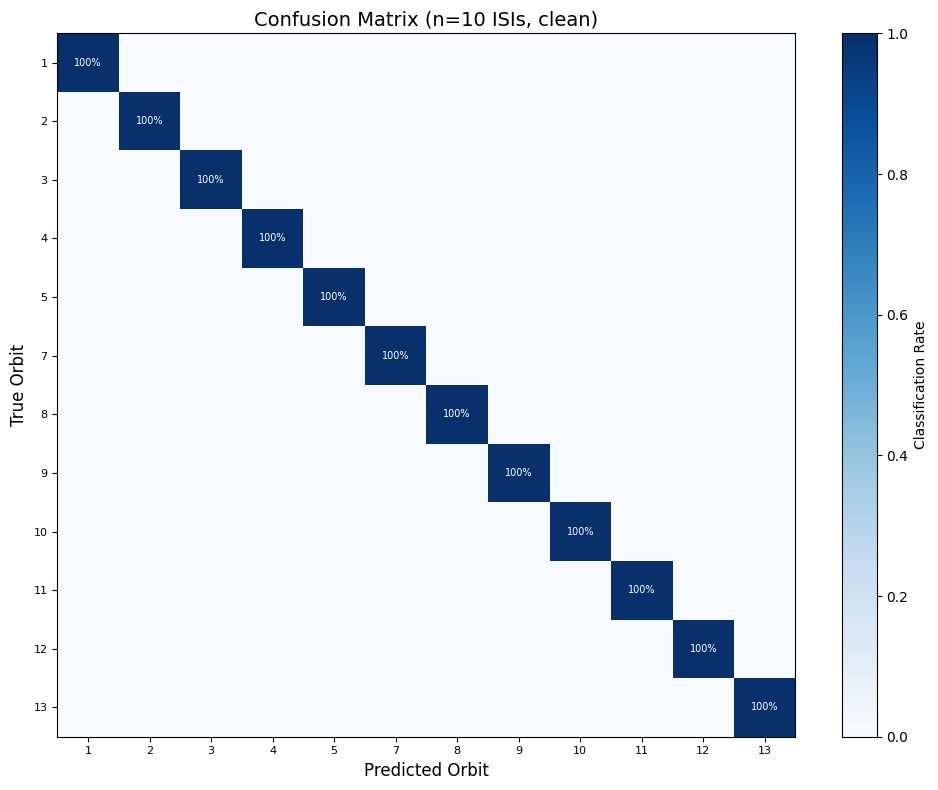


PHASE C — Observation Window Calibration

Phase C: Observation Window Calibration
  12 orbits × 8 windows × 50 trials
  Window sizes (ISIs): [3, 5, 8, 10, 15, 20, 30, 50]
  [ 1/12]   burst_p6 ISI=   7.3: 100% 100% 100% 100% 100% 100% 100% 100%
  [ 2/12]  burst_p10 ISI=   8.9: 100% 100% 100% 100% 100% 100% 100% 100%
  [ 3/12]   burst_p9 ISI=  10.3: 100% 100% 100% 100% 100% 100% 100% 100%
  [ 4/12]   burst_p7 ISI=  11.9: 100% 100% 100% 100% 100% 100% 100% 100%
  [ 5/12]    triplet ISI=  13.4: 100% 100% 100% 100% 100% 100% 100% 100%
  [ 6/12]   burst_p8 ISI=  16.8: 100% 100% 100% 100% 100% 100% 100% 100%
  [ 7/12]   burst_p5 ISI=  18.0: 100% 100% 100% 100% 100% 100% 100% 100%
  [ 8/12]  burst_p11 ISI=  19.5: 100% 100% 100% 100% 100% 100% 100% 100%
  [ 9/12]   burst_p7 ISI=  21.0: 100% 100% 100% 100% 100% 100% 100% 100%
  [10/12]   burst_p4 ISI=  25.9: 100% 100% 100% 100% 100% 100% 100% 100%
  [11/12]      tonic ISI=  42.6:  94% 100% 100% 100% 100% 100% 100% 100%
  [12/12]    doublet ISI=

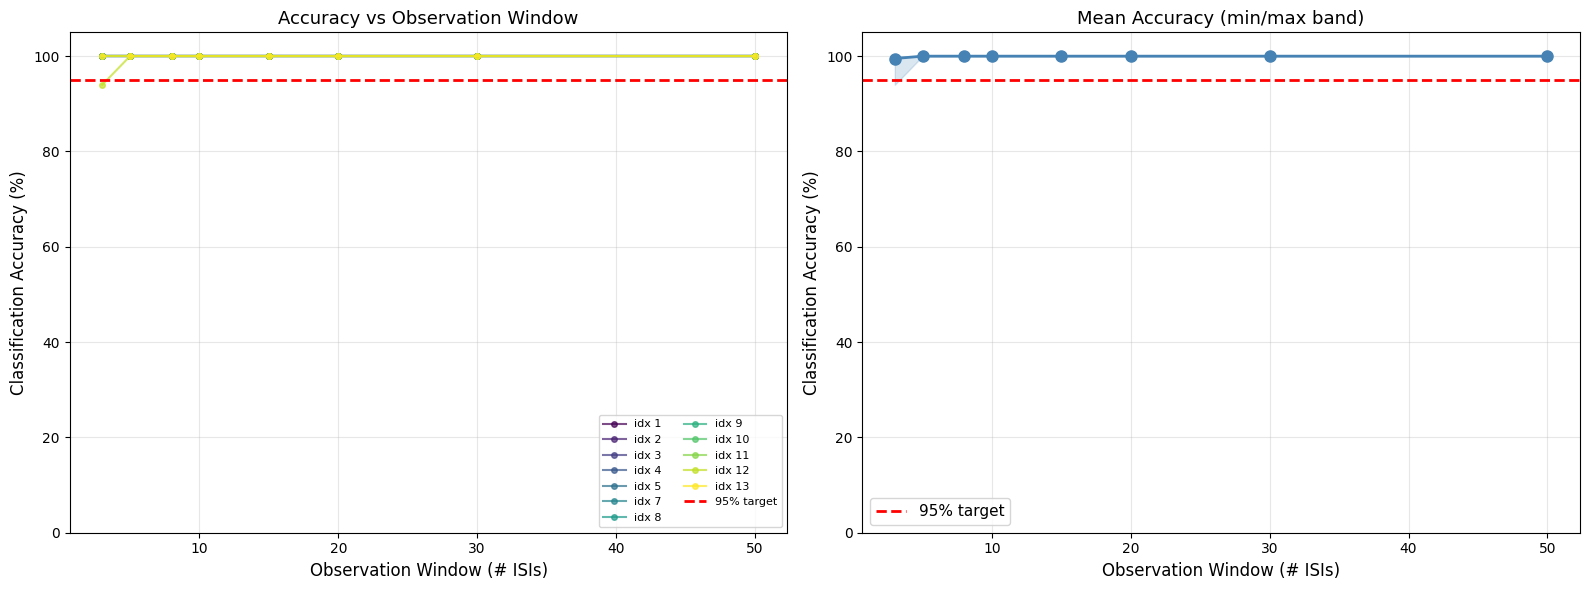


PHASE D — Noise Robustness Testing

Phase D: Noise Robustness Testing
  Test 1: Current noise (8 levels × 12 orbits × 50 trials)
  Current noise test: 628.4s
    σ= 0.0 μA/cm²: 100.0%
    σ= 0.1 μA/cm²: 99.8%
    σ= 0.2 μA/cm²: 99.7%
    σ= 0.5 μA/cm²: 99.7%
    σ= 1.0 μA/cm²: 99.8%
    σ= 2.0 μA/cm²: 99.5%
    σ= 3.0 μA/cm²: 99.5%
    σ= 5.0 μA/cm²: 99.7%

  Test 2: K jitter (6 levels)
  K jitter test: 469.3s
    K±0%: 100.0%
    K±2%: 97.7%
    K±5%: 92.8%
    K±10%: 89.7%
    K±15%: 83.5%
    K±20%: 75.7%

  Test 3: τ jitter (6 levels)
  τ jitter test: 486.0s
    τ±0%: 100.0%
    τ±2%: 84.3%
    τ±5%: 77.8%
    τ±10%: 67.8%
    τ±15%: 50.3%
    τ±20%: 44.5%


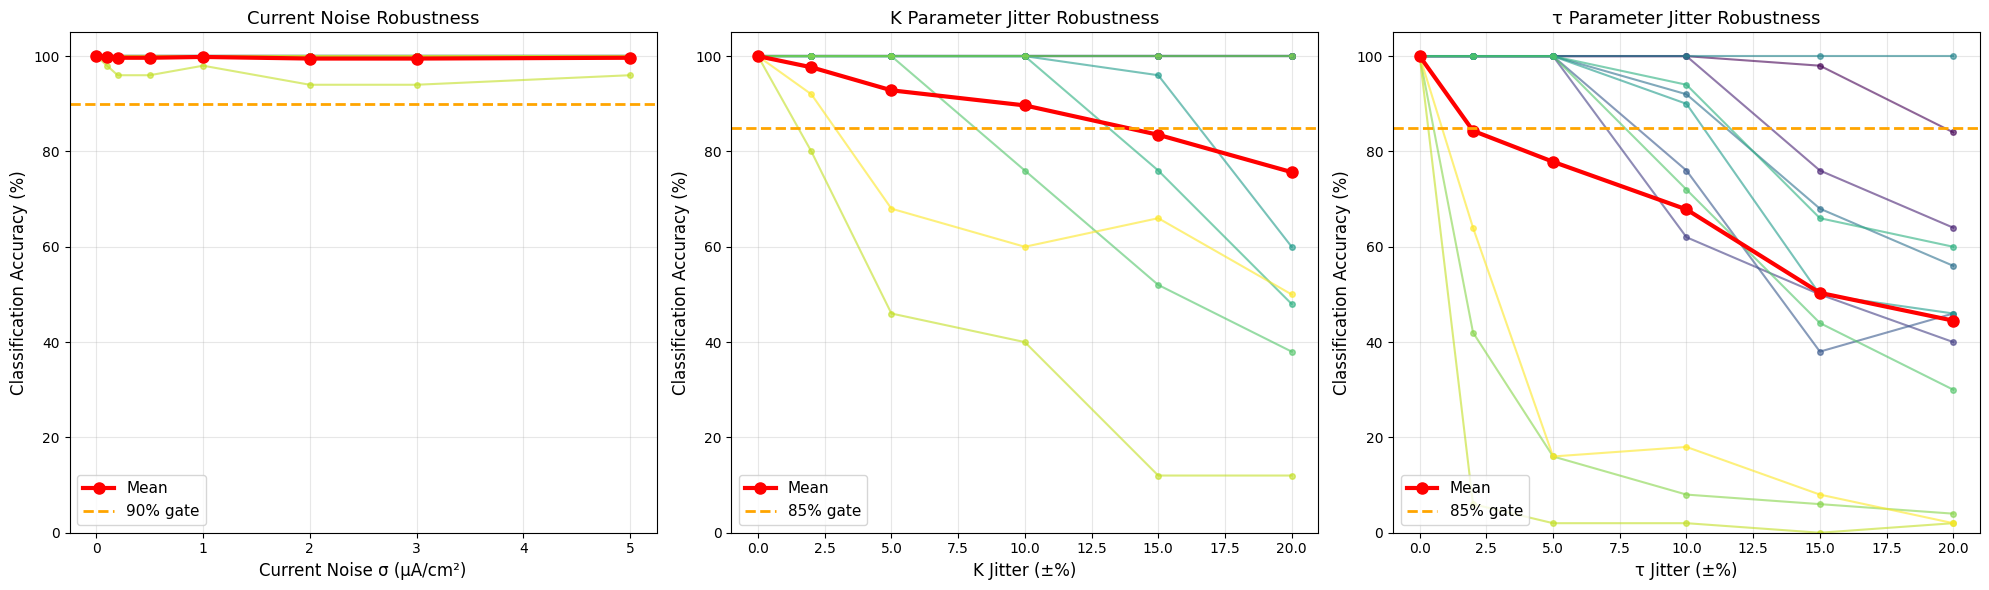




GATE PS-G2 — READ PROTOCOL VIABILITY

  G2a — Clean accuracy at 10 ISIs: 100.0% ✓ PASS (gate: ≥95%)
  G2b — Noisy accuracy (σ=0.5): 99.7% ✓ PASS (gate: ≥90%)
  G2c — Jitter accuracy (K±10%: 89.7%, τ±10%: 67.8%) ✗ FAIL (gate: min ≥85%)
  G2d — Max min-window (≥95%): 5 ISIs ✓ PASS (gate: all ≤20)

  ✗✗✗ GATE PS-G2: CONDITIONAL ✗✗✗
  Rec: Increase parameter precision or widen ISI separation

PS2 COMPLETE — ALL RESULTS SAVED
Output directory: /content/drive/My Drive/HHSMC/full_study/PS2_read_protocol
Files:
  PS2_templates.json         — Orbit fingerprint templates
  PS2_calibration.json       — Observation window calibration
  PS2_noise_data.npz         — Noise robustness raw data
  gate_PS_G2_result.json     — Gate decision
  PS2_confusion_matrix.png   — Clean classification heatmap
  PS2_observation_window.png — Accuracy vs window size
  PS2_noise_robustness.png   — Noise/jitter robustness curves

Gate PS-G2: CONDITIONAL
  → See recommendations above, then retry or prune library


In [12]:
if __name__ == '__main__' or True:

    print("="*70)
    print("PS2 — READ PROTOCOL & ORBIT CLASSIFICATION")
    print("Option C: HH Delay-Directed Orbit Selection")
    print("="*70)

    I_BIAS = 10.0

    # ==== LOAD PS1 ====
    print("\n" + "="*50)
    print("Loading PS1 Library")
    print("="*50)
    library, settling, locked_idx = load_ps1_library(PS1_DIR)

    # ==== PHASE A: TEMPLATES ====
    print("\n" + "="*50)
    print("PHASE A — Build Orbit Fingerprint Templates")
    print("="*50)
    templates = build_templates(library, locked_idx, I_BIAS,
                                T_sim=5000.0, T_transient=1000.0,
                                n_template_runs=5)

    with open(os.path.join(OUTPUT_DIR, 'PS2_templates.json'), 'w') as f:
        json.dump(clean_for_json(templates), f, indent=2)
    print(f"\nTemplates saved ({len(templates)} orbit templates)")

    # ==== PHASE B: CONFUSION MATRIX ====
    print("\n" + "="*50)
    print("PHASE B — Clean Classification Confusion Matrix")
    print("="*50)
    conf_matrix = plot_confusion_matrix(templates, library, locked_idx,
                                        I_BIAS, n_isis=10, n_trials=100,
                                        save_dir=OUTPUT_DIR)

    # ==== PHASE C: OBSERVATION WINDOW ====
    print("\n" + "="*50)
    print("PHASE C — Observation Window Calibration")
    print("="*50)
    calibration = calibrate_observation_window(
        templates, library, locked_idx, I_BIAS,
        window_sizes=[3, 5, 8, 10, 15, 20, 30, 50],
        n_trials=50
    )

    plot_observation_window(calibration, save_dir=OUTPUT_DIR)

    with open(os.path.join(OUTPUT_DIR, 'PS2_calibration.json'), 'w') as f:
        json.dump(clean_for_json(calibration), f, indent=2)

    # ==== PHASE D: NOISE ROBUSTNESS ====
    print("\n" + "="*50)
    print("PHASE D — Noise Robustness Testing")
    print("="*50)
    noise_data = test_noise_robustness(
        templates, library, locked_idx, I_BIAS,
        noise_levels=[0.0, 0.1, 0.2, 0.5, 1.0, 2.0, 3.0, 5.0],
        K_jitter_levels=[0.0, 0.02, 0.05, 0.10, 0.15, 0.20],
        tau_jitter_levels=[0.0, 0.02, 0.05, 0.10, 0.15, 0.20],
        n_isis_read=10, n_trials=50
    )

    plot_noise_robustness(noise_data, save_dir=OUTPUT_DIR)

    np.savez_compressed(
        os.path.join(OUTPUT_DIR, 'PS2_noise_data.npz'),
        noise_accuracy=noise_data['noise_accuracy'],
        K_jitter_accuracy=noise_data['K_jitter_accuracy'],
        tau_jitter_accuracy=noise_data['tau_jitter_accuracy'],
    )

    # ==== GATE PS-G2 ====
    print("\n")
    gate_result = evaluate_gate_PS_G2(calibration, noise_data,
                                       templates, library)

    with open(os.path.join(OUTPUT_DIR, 'gate_PS_G2_result.json'), 'w') as f:
        json.dump(clean_for_json(gate_result), f, indent=2)

    # ==== FINAL SUMMARY ====
    print(f"\n{'='*70}")
    print(f"PS2 COMPLETE — ALL RESULTS SAVED")
    print(f"{'='*70}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Files:")
    print(f"  PS2_templates.json         — Orbit fingerprint templates")
    print(f"  PS2_calibration.json       — Observation window calibration")
    print(f"  PS2_noise_data.npz         — Noise robustness raw data")
    print(f"  gate_PS_G2_result.json     — Gate decision")
    print(f"  PS2_confusion_matrix.png   — Clean classification heatmap")
    print(f"  PS2_observation_window.png — Accuracy vs window size")
    print(f"  PS2_noise_robustness.png   — Noise/jitter robustness curves")
    print(f"\nGate PS-G2: {gate_result['decision']}")
    if gate_result['decision'] == 'PASS':
        print(f"  → PROCEED TO PHASE PS3 (Full Write-Read-Erase Demo)")
    else:
        print(f"  → See recommendations above, then retry or prune library")